# Custom Derivatives in JAX

This notebook covers how to define custom gradient rules in JAX, which is essential for:

- Implementing non-standard operations (e.g., numerical solvers)
- Improving numerical stability of gradients
- Skipping expensive forward computations during backprop
- Stopping gradient flow through certain computations

**Topics covered:**
1. `jax.lax.stop_gradient` - Skipping functions in derivatives
2. `jax.custom_vjp` - Custom reverse-mode gradients
3. `jax.custom_jvp` - Custom forward-mode gradients
4. `nondiff_argnums` - Non-differentiable arguments
5. Practical examples: implicit differentiation, straight-through estimators

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, jacfwd, jacrev
from jax import lax
from jax import custom_vjp, custom_jvp
from functools import partial
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## 1. Stopping Gradient Flow with `stop_gradient`

Sometimes you want to **skip** certain computations during backpropagation. The `jax.lax.stop_gradient` function treats its input as a constant during differentiation.

### Use cases:
- Target values in reinforcement learning
- Detaching parts of a computation graph
- Implementing stop-gradient tricks in optimization

In [2]:
# Basic example: stop_gradient

def with_gradient(x):
    """Normal function - gradients flow through."""
    return x ** 2 + 3 * x

def without_gradient(x):
    """The squared term is treated as constant."""
    return lax.stop_gradient(x ** 2) + 3 * x

x = 2.0

print(f"f(x) = x² + 3x at x = {x}")
print(f"Normal gradient: d/dx[x² + 3x] = 2x + 3 = {grad(with_gradient)(x)}")
print(f"With stop_gradient on x²: d/dx[const + 3x] = 3 = {grad(without_gradient)(x)}")

f(x) = x² + 3x at x = 2.0
Metal device set to: Apple M4 Pro
Normal gradient: d/dx[x² + 3x] = 2x + 3 = 7.0
With stop_gradient on x²: d/dx[const + 3x] = 3 = 3.0


W0000 00:00:1767316081.850913 9824588 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767316081.859323 9824588 service.cc:145] XLA service 0x600001008a00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767316081.859333 9824588 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767316081.860323 9824588 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767316081.860330 9824588 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


In [3]:
# Practical example: Target networks in RL
# In Q-learning, we compute loss = (Q(s,a) - target)²
# where target = r + γ * max_a' Q_target(s', a')
# The target should NOT receive gradients!

def td_loss_wrong(q_value, target_q_value):
    """Wrong: gradients flow to both terms."""
    return (q_value - target_q_value) ** 2

def td_loss_correct(q_value, target_q_value):
    """Correct: target is treated as constant."""
    return (q_value - lax.stop_gradient(target_q_value)) ** 2

q = 5.0
target = 3.0

# Gradient w.r.t. both inputs
grad_wrong = grad(td_loss_wrong, argnums=(0, 1))(q, target)
grad_correct = grad(td_loss_correct, argnums=(0, 1))(q, target)

print("TD Loss gradients:")
print(f"  Without stop_gradient: dL/dq = {grad_wrong[0]}, dL/dtarget = {grad_wrong[1]}")
print(f"  With stop_gradient:    dL/dq = {grad_correct[0]}, dL/dtarget = {grad_correct[1]}")
print("\nNote: With stop_gradient, the target gradient is 0!")

TD Loss gradients:
  Without stop_gradient: dL/dq = 4.0, dL/dtarget = -4.0
  With stop_gradient:    dL/dq = 4.0, dL/dtarget = 0.0

Note: With stop_gradient, the target gradient is 0!


In [4]:
# More complex example: Partial gradient through a computation

def complex_function(x):
    """Only differentiate through part of the computation."""
    # Expensive computation we don't want gradients through
    expensive_part = jnp.sin(x ** 2) * jnp.exp(-x)
    
    # Use the value but block gradients
    detached = lax.stop_gradient(expensive_part)
    
    # Simple part we DO want gradients through
    simple_part = x * detached
    
    return simple_part

x = 1.0
print(f"f(x) = x * stop_gradient(sin(x²)exp(-x))")
print(f"f({x}) = {complex_function(x):.6f}")
print(f"df/dx = stop_gradient(sin(x²)exp(-x)) = {grad(complex_function)(x):.6f}")
print(f"(The inner expression is treated as a constant: {jnp.sin(x**2) * jnp.exp(-x):.6f})")

f(x) = x * stop_gradient(sin(x²)exp(-x))
f(1.0) = 0.309560


df/dx = stop_gradient(sin(x²)exp(-x)) = 0.309560
(The inner expression is treated as a constant: 0.309560)


## 2. Custom Reverse-Mode Gradients with `custom_vjp`

When you need **complete control** over the backward pass, use `custom_vjp`. This is useful for:

- Implementing gradients through iterative algorithms
- Numerical stability improvements
- Implicit differentiation

### The `custom_vjp` pattern:

1. Define the forward function
2. Define `fwd`: returns (output, residuals_for_backward)
3. Define `bwd`: takes (residuals, output_gradient) → input_gradients

In [5]:
# Example 1: Custom gradient for numerical stability
# log(1 + exp(x)) has numerical issues for large x
# Standard implementation can overflow, but we can define stable gradients

@custom_vjp
def safe_softplus(x):
    """Numerically stable softplus: log(1 + exp(x))"""
    return jnp.where(x > 20, x, jnp.log1p(jnp.exp(x)))

def safe_softplus_fwd(x):
    """Forward pass: return output and save x for backward."""
    y = safe_softplus(x)
    return y, x  # (output, residuals)

def safe_softplus_bwd(x, g):
    """Backward pass: gradient is sigmoid(x)."""
    # d/dx log(1 + exp(x)) = exp(x)/(1 + exp(x)) = sigmoid(x)
    return (g * jax.nn.sigmoid(x),)  # Must return tuple!

safe_softplus.defvjp(safe_softplus_fwd, safe_softplus_bwd)

# Test
x_test = jnp.array([0.0, 10.0, 100.0, 1000.0])
print("Safe softplus with custom gradient:")
for x in x_test:
    y = safe_softplus(x)
    dy = grad(safe_softplus)(x)
    print(f"  x={x:6.1f}: softplus={y:10.4f}, gradient={dy:.6f}")

Safe softplus with custom gradient:
  x=   0.0: softplus=    0.6931, gradient=0.500000
  x=  10.0: softplus=   10.0000, gradient=0.999955
  x= 100.0: softplus=  100.0000, gradient=1.000000
  x=1000.0: softplus= 1000.0000, gradient=1.000000


In [6]:
# Example 2: Implicit differentiation through a fixed-point iteration
# Solve: x = cos(x) (find fixed point)
# Instead of differentiating through all iterations, use implicit diff!

# nondiff_argnums specifies which args (tol, max_iter) are non-differentiable
@partial(custom_vjp, nondiff_argnums=(1, 2))
def fixed_point_cos(x0, tol=1e-10, max_iter=100):
    """
    Find x such that x = cos(x), starting from x0.
    Returns the fixed point (independent of x0 in exact arithmetic).
    """
    def body(carry):
        x, _ = carry
        x_new = jnp.cos(x)
        return (x_new, x)
    
    def cond(carry):
        x, x_prev = carry
        return jnp.abs(x - x_prev) > tol
    
    x_final, _ = lax.while_loop(cond, body, (x0, x0 + 1.0))
    return x_final

def fixed_point_cos_fwd(x0, tol, max_iter):
    """Forward pass - same signature as primal."""
    x_star = fixed_point_cos(x0, tol, max_iter)
    return x_star, x_star  # Save fixed point for backward

def fixed_point_cos_bwd(tol, max_iter, x_star, g):
    """
    Backward pass - nondiff args come first, then residuals, then g.
    
    At fixed point: x* = cos(x*)
    But x* doesn't depend on x0 (it's the unique fixed point)!
    So dx*/dx0 = 0.
    """
    # Fixed point of cos doesn't depend on initial guess
    return (0.0,)  # No gradient w.r.t. x0 (only differentiable arg)

fixed_point_cos.defvjp(fixed_point_cos_fwd, fixed_point_cos_bwd)

# Test
x0_values = [0.0, 0.5, 1.0, 2.0]
print("Fixed point of cos(x):")
for x0 in x0_values:
    x_star = fixed_point_cos(x0)
    grad_x0 = grad(fixed_point_cos)(x0)
    print(f"  x0={x0}: x* = {x_star:.10f}, dx*/dx0 = {grad_x0}")

print(f"\nVerification: cos(x*) = {jnp.cos(fixed_point_cos(0.5)):.10f}")

Fixed point of cos(x):
  x0=0.0: x* = 0.7390851332, dx*/dx0 = 0.0
  x0=0.5: x* = 0.7390851333, dx*/dx0 = 0.0
  x0=1.0: x* = 0.7390851332, dx*/dx0 = 0.0


  x0=2.0: x* = 0.7390851332, dx*/dx0 = 0.0

Verification: cos(x*) = 0.7390851332


In [7]:
# Example 3: Implicit differentiation through a root-finding problem
# Solve f(x, θ) = 0 for x given θ
# df*/dθ = -(df/dx)^{-1} * df/dθ

@custom_vjp
def solve_cubic(theta):
    """
    Solve x³ - θ = 0 for x.
    Solution: x = θ^(1/3)
    """
    # Newton's method
    def newton_step(x):
        f = x**3 - theta
        df = 3 * x**2
        return x - f / df
    
    x = jnp.abs(theta) ** (1/3) * jnp.sign(theta)  # Good initial guess
    for _ in range(10):
        x = newton_step(x)
    return x

def solve_cubic_fwd(theta):
    x_star = solve_cubic(theta)
    return x_star, (x_star, theta)

def solve_cubic_bwd(res, g):
    """
    Implicit differentiation:
    f(x, θ) = x³ - θ = 0
    df/dx = 3x², df/dθ = -1
    dx*/dθ = -(df/dx)^{-1} * df/dθ = -1/(3x²) * (-1) = 1/(3x²)
    """
    x_star, theta = res
    dx_dtheta = 1.0 / (3 * x_star**2)
    return (g * dx_dtheta,)

solve_cubic.defvjp(solve_cubic_fwd, solve_cubic_bwd)

# Test
theta = 8.0
x_star = solve_cubic(theta)
grad_theta = grad(solve_cubic)(theta)

print(f"Solving x³ = θ for θ = {theta}")
print(f"Solution: x* = {x_star:.10f} (should be {theta**(1/3):.10f})")
print(f"Gradient dx*/dθ = {grad_theta:.10f}")
print(f"Expected: 1/(3x²) = {1/(3*x_star**2):.10f}")
print(f"Also: (1/3)θ^(-2/3) = {(1/3) * theta**(-2/3):.10f}")

Solving x³ = θ for θ = 8.0
Solution: x* = 2.0000000000 (should be 2.0000000000)
Gradient dx*/dθ = 0.0833333333
Expected: 1/(3x²) = 0.0833333333
Also: (1/3)θ^(-2/3) = 0.0833333333


## 3. Custom Forward-Mode Gradients with `custom_jvp`

While `custom_vjp` handles reverse-mode (backprop), `custom_jvp` handles forward-mode differentiation.

### When to use `custom_jvp`:
- When forward-mode is more efficient (few inputs, many outputs)
- When you need JVP for higher-order derivatives
- When the JVP is simpler to express than VJP

In [8]:
# Example: Custom JVP for a special function

@custom_jvp
def my_sin(x):
    """Just sin(x), but we'll define custom forward-mode derivative."""
    return jnp.sin(x)

@my_sin.defjvp
def my_sin_jvp(primals, tangents):
    """
    JVP rule: returns (primal_output, tangent_output)
    
    For y = sin(x):
    dy = cos(x) * dx
    """
    x, = primals
    x_dot, = tangents
    y = my_sin(x)
    y_dot = jnp.cos(x) * x_dot
    return y, y_dot

# Test with forward-mode AD
from jax import jvp

x = jnp.pi / 4
y, y_dot = jvp(my_sin, (x,), (1.0,))  # tangent = 1.0 gives the derivative

print(f"my_sin(π/4) = {y:.10f} (should be {jnp.sin(x):.10f})")
print(f"d(my_sin)/dx = {y_dot:.10f} (should be cos(π/4) = {jnp.cos(x):.10f})")

my_sin(π/4) = 0.7071067812 (should be 0.7071067812)
d(my_sin)/dx = 0.7071067812 (should be cos(π/4) = 0.7071067812)


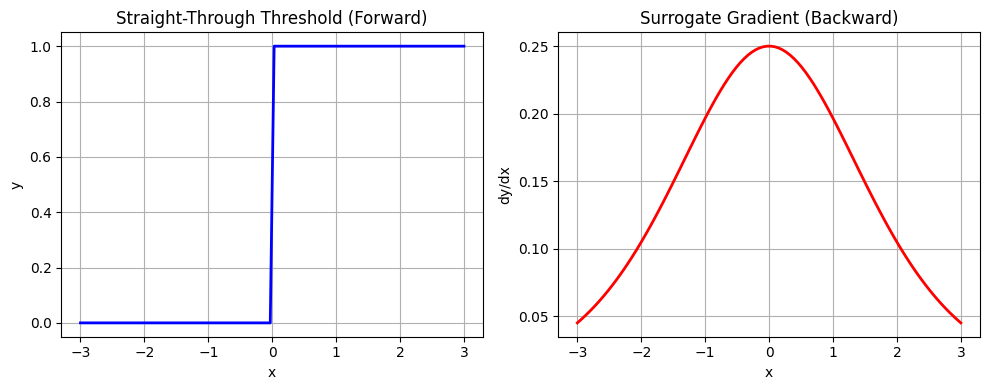

In [9]:
# More interesting example: Straight-through estimator
# Forward: hard threshold (non-differentiable)
# Backward: approximate with sigmoid

@custom_jvp
def straight_through_threshold(x):
    """Hard threshold at 0."""
    return jnp.where(x > 0, 1.0, 0.0)

@straight_through_threshold.defjvp
def straight_through_threshold_jvp(primals, tangents):
    """
    JVP: Use sigmoid derivative as surrogate gradient.
    """
    x, = primals
    x_dot, = tangents
    
    # Forward: hard threshold
    y = straight_through_threshold(x)
    
    # Backward: sigmoid gradient (temperature can be tuned)
    temperature = 1.0
    sigmoid_grad = jax.nn.sigmoid(x / temperature) * (1 - jax.nn.sigmoid(x / temperature)) / temperature
    y_dot = sigmoid_grad * x_dot
    
    return y, y_dot

# Visualize
x_range = jnp.linspace(-3, 3, 100)
y_values = vmap(straight_through_threshold)(x_range)
grad_values = vmap(grad(straight_through_threshold))(x_range)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_range, y_values, 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Straight-Through Threshold (Forward)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_range, grad_values, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('dy/dx')
plt.title('Surrogate Gradient (Backward)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Non-Differentiable Arguments with `nondiff_argnums`

Sometimes functions have arguments that **shouldn't be differentiated** (e.g., integers, booleans, configuration). Use `nondiff_argnums` to specify these.

In [10]:
# Example: Function with configuration argument
# nondiff_argnums goes in the decorator, not defvjp()

@partial(custom_vjp, nondiff_argnums=(1, 2))
def power_with_mode(x, n, use_abs=False):
    """
    Compute x^n, optionally using |x|.
    n and use_abs are not differentiable.
    """
    if use_abs:
        return jnp.abs(x) ** n
    return x ** n

def power_with_mode_fwd(x, n, use_abs):
    """Forward pass - same signature as primal."""
    y = power_with_mode(x, n, use_abs)
    return y, x  # Only need to save x for backward

def power_with_mode_bwd(n, use_abs, x, g):
    """Backward pass - nondiff args (n, use_abs) come first, then residuals (x), then g."""
    if use_abs:
        # d/dx |x|^n = n * |x|^(n-1) * sign(x)
        grad_x = g * n * jnp.abs(x) ** (n - 1) * jnp.sign(x)
    else:
        # d/dx x^n = n * x^(n-1)
        grad_x = g * n * x ** (n - 1)
    return (grad_x,)  # Only gradient for x

power_with_mode.defvjp(power_with_mode_fwd, power_with_mode_bwd)

# Test
x = 2.0
print(f"power_with_mode({x}, n=3, use_abs=False) = {power_with_mode(x, 3, False)}")
print(f"Gradient: {grad(power_with_mode)(x, 3, False)} (expected: 3*x² = {3*x**2})")

x = -2.0
print(f"\npower_with_mode({x}, n=3, use_abs=True) = {power_with_mode(x, 3, True)}")
print(f"Gradient: {grad(power_with_mode)(x, 3, True)} (expected: -3*|x|² = {-3*abs(x)**2})")

power_with_mode(2.0, n=3, use_abs=False) = 8.0
Gradient: 12.0 (expected: 3*x² = 12.0)

power_with_mode(-2.0, n=3, use_abs=True) = 8.0


Gradient: -12.0 (expected: -3*|x|² = -12.0)


## 5. Practical Example: Differentiable Sorting

Sorting is not differentiable, but we can define a relaxed version with custom gradients.

In [11]:
# Soft sorting using a differentiable relaxation

@partial(custom_vjp, nondiff_argnums=(1,))
def soft_sort(x, temperature=1.0):
    """
    Differentiable approximation to sorting.
    Uses soft assignment based on pairwise comparisons.
    """
    n = len(x)
    
    # For each position i, compute soft weights for which element should go there
    # Element j should be at position i if j is the i-th smallest
    
    # Pairwise comparison: how much is x[i] > x[j]?
    diff_matrix = x[:, None] - x[None, :]  # (n, n)
    comparison = jax.nn.sigmoid(diff_matrix / temperature)
    
    # Sum columns to get "rank" of each element
    ranks = comparison.sum(axis=0)  # Higher rank = larger element
    
    # Convert ranks to soft permutation matrix
    positions = jnp.arange(n)
    rank_diff = ranks[:, None] - positions[None, :]  # (n, n)
    perm_matrix = jax.nn.softmax(-rank_diff**2 / temperature, axis=0)
    
    # Apply permutation
    sorted_x = perm_matrix.T @ x
    
    return sorted_x

def soft_sort_fwd(x, temperature):
    """Forward pass - same signature as primal."""
    y = soft_sort(x, temperature)
    return y, x  # Save x for backward

def soft_sort_bwd(temperature, x, g):
    """Backward pass - nondiff arg (temperature) comes first, then residuals (x), then g."""
    # Use JAX's autodiff for the backward pass
    # This works because soft_sort is composed of differentiable ops
    grad_x = jacrev(lambda x_: soft_sort(x_, temperature))(x).T @ g
    return (grad_x,)

soft_sort.defvjp(soft_sort_fwd, soft_sort_bwd)

# Test
x = jnp.array([3.0, 1.0, 4.0, 1.0, 5.0])
print(f"Original: {x}")
print(f"Hard sort: {jnp.sort(x)}")
print(f"Soft sort (temp=0.1): {soft_sort(x, temperature=0.1)}")
print(f"Soft sort (temp=1.0): {soft_sort(x, temperature=1.0)}")

Original: [3. 1. 4. 1. 5.]
Hard sort: [1. 1. 3. 4. 5.]
Soft sort (temp=0.1): [5.         4.50011349 3.49988652 2.99778911 1.        ]
Soft sort (temp=1.0): [4.82967932 4.4469188  3.62642247 1.97001939 1.0704668 ]


## 6. Practical Example: Implicit Layer

Neural networks can include **implicit layers** where the output is defined as the solution to an optimization problem. We use `custom_vjp` to differentiate through the solution.

In [12]:
# Implicit layer: output is the solution to Ax = b
# We want gradients w.r.t. A and b

@custom_vjp
def solve_linear_system(A, b):
    """Solve Ax = b for x."""
    return jnp.linalg.solve(A, b)

def solve_linear_system_fwd(A, b):
    x = solve_linear_system(A, b)
    return x, (A, x)

def solve_linear_system_bwd(res, g):
    """
    Implicit differentiation:
    Ax = b
    A dx + dA x = db
    dx = A^{-1}(db - dA x)
    
    For VJP with output gradient g:
    g^T dx = g^T A^{-1} db - g^T A^{-1} dA x
    
    So:
    grad_b = A^{-T} g
    grad_A = -A^{-T} g x^T (using the identity for matrix gradients)
    """
    A, x = res
    
    # Solve A^T v = g
    v = jnp.linalg.solve(A.T, g)
    
    grad_b = v
    grad_A = -jnp.outer(v, x)
    
    return (grad_A, grad_b)

solve_linear_system.defvjp(solve_linear_system_fwd, solve_linear_system_bwd)

# Test
A = jnp.array([[2.0, 1.0], [1.0, 3.0]])
b = jnp.array([1.0, 2.0])

x = solve_linear_system(A, b)
print(f"Solution x = {x}")
print(f"Verification Ax = {A @ x} (should be {b})")

# Compute gradient of x[0] w.r.t. A and b
def objective(A, b):
    x = solve_linear_system(A, b)
    return x[0]

grad_A, grad_b = grad(objective, argnums=(0, 1))(A, b)
print(f"\nGradient of x[0] w.r.t. b: {grad_b}")
print(f"Gradient of x[0] w.r.t. A:\n{grad_A}")

Solution x = [0.2 0.6]
Verification Ax = [1. 2.] (should be [1. 2.])

Gradient of x[0] w.r.t. b: [ 0.6 -0.2]
Gradient of x[0] w.r.t. A:
[[-0.12 -0.36]
 [ 0.04  0.12]]


## 7. Common Patterns Summary

### Pattern 1: Stopping gradients
```python
# Use stop_gradient to treat part of computation as constant
def loss(x, target):
    return (x - lax.stop_gradient(target)) ** 2
```

### Pattern 2: Custom VJP for reverse-mode
```python
@custom_vjp
def my_function(x):
    return ...

def my_function_fwd(x):
    y = my_function(x)
    return y, residuals  # Save what you need for backward

def my_function_bwd(residuals, g):
    return (grad_x,)  # Tuple of gradients for each input

my_function.defvjp(my_function_fwd, my_function_bwd)
```

### Pattern 3: Custom JVP for forward-mode
```python
@custom_jvp
def my_function(x):
    return ...

@my_function.defjvp
def my_function_jvp(primals, tangents):
    x, = primals
    x_dot, = tangents
    y = my_function(x)
    y_dot = ...  # Compute tangent output
    return y, y_dot
```

### Pattern 4: Non-differentiable arguments
```python
from functools import partial

# nondiff_argnums goes in the decorator
@partial(custom_vjp, nondiff_argnums=(1,))
def f(x, config):
    return ...

def f_fwd(x, config):
    # Same signature as primal
    return f(x, config), x  # residuals

def f_bwd(config, x, g):
    # nondiff args come FIRST, then residuals, then g
    return (grad_x,)  # Only gradient for differentiable args

f.defvjp(f_fwd, f_bwd)
```

In [13]:
# Final example: Combining everything
# A differentiable argmax using straight-through estimation

@partial(custom_vjp, nondiff_argnums=(1,))
def differentiable_argmax(logits, temperature=1.0):
    """
    Forward: hard argmax (one-hot)
    Backward: softmax gradient
    """
    idx = jnp.argmax(logits)
    return jax.nn.one_hot(idx, len(logits))

def differentiable_argmax_fwd(logits, temperature):
    """Forward pass - same signature as primal."""
    y = differentiable_argmax(logits, temperature)
    return y, logits  # Save logits for backward

def differentiable_argmax_bwd(temperature, logits, g):
    """Backward pass - nondiff arg (temperature) comes first, then residuals, then g."""
    # Softmax gradient as surrogate
    softmax = jax.nn.softmax(logits / temperature)
    
    # Jacobian of softmax: diag(s) - s s^T
    jacobian = jnp.diag(softmax) - jnp.outer(softmax, softmax)
    
    grad_logits = jacobian.T @ g / temperature
    return (grad_logits,)

differentiable_argmax.defvjp(differentiable_argmax_fwd, differentiable_argmax_bwd)

# Test
logits = jnp.array([1.0, 2.0, 0.5])
one_hot = differentiable_argmax(logits)
print(f"Logits: {logits}")
print(f"One-hot (hard argmax): {one_hot}")
print(f"Softmax (for reference): {jax.nn.softmax(logits)}")

# Gradient of sum(one_hot * logits) w.r.t. logits
def score(logits):
    return jnp.sum(differentiable_argmax(logits) * logits)

print(f"\nGradient of selected logit w.r.t. all logits:")
print(f"{grad(score)(logits)}")

Logits: [1.  2.  0.5]
One-hot (hard argmax): [0. 1. 0.]
Softmax (for reference): [0.2312239  0.62853172 0.14024438]

Gradient of selected logit w.r.t. all logits:


[-0.12911763  1.27755362 -0.14843599]


## Summary

This notebook covered:

1. **`lax.stop_gradient`** - Block gradient flow through parts of computation
2. **`custom_vjp`** - Define custom reverse-mode (backprop) gradients
3. **`custom_jvp`** - Define custom forward-mode gradients
4. **`nondiff_argnums`** - Mark arguments that shouldn't be differentiated

### Key use cases:

- **Numerical stability**: Custom gradients that avoid numerical issues
- **Implicit differentiation**: Gradients through iterative solvers
- **Straight-through estimators**: Differentiable approximations to discrete operations
- **Efficiency**: Skip expensive forward computations during backprop
- **Detaching**: Stop gradients for target networks, etc.

### Best practices:

1. Always return a **tuple** from the backward function, even for single inputs
2. Use `nondiff_argnums` for configuration/hyperparameters
3. Save only what you need in the forward pass (residuals)
4. Test your custom gradients against numerical differentiation